In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "rank-bm25", "-q"], check=False)

import os, re, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from rank_bm25 import BM25Okapi

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

SAVE_DIR = r'C:\Users\sribaladitya\ir_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)
print("All libraries loaded.")
print(f"Artifacts saved to: {SAVE_DIR}")


In [ ]:
df = pd.read_csv(r'C:\Users\sribaladitya\combined_leetcode_dataset.csv')

for col in ["frequency","difficulty_num","acceptance_rate","likes","dislikes","relevance_score","freq_score"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
df["topics"] = df["topics"].fillna("Unknown")
df.reset_index(drop=True, inplace=True)
df["doc_id"] = df.index

print(f"Dataset: {df.shape[0]} rows | {df['company'].nunique()} companies")
display(df.head(4))


Dataset: 3833 rows | 187 companies


,problem_id,title,company,frequency,difficulty,topics,acceptance_rate,premium,category,likes,dislikes,url,freq_score,difficulty_num,relevance_score,doc_id
0,2260,Minimum Consecutive Cards to Pick Up,Google,1.0,Medium,"Array, Hash Table, Sliding Window",52.88,False,Algorithms,1062,44,https://leetcode.com/problems/minimum-consecut...,0.0133,2,0.2080,0
1,2259,Remove Digit From Number to Maximize Result,Microsoft,2.0,Easy,"String, Greedy, Enumeration",47.61,False,Algorithms,918,64,https://leetcode.com/problems/remove-digit-fro...,0.0385,1,0.4231,1
2,2256,Minimum Average Difference,Amazon,1.0,Medium,"Array, Prefix Sum",43.60,False,Algorithms,1552,180,https://leetcode.com/problems/minimum-average-...,0.0000,2,0.2000,2
3,2255,Count Prefixes of a Given String,Google,1.0,Easy,"Array, String",74.00,False,Algorithms,589,24,https://leetcode.com/problems/count-prefixes-o...,0.0133,1,0.4080,3


In [3]:
def parse_topics(raw):
    if not raw or str(raw).strip().lower() in ("unknown", "nan", ""):
        return []
    return [t.strip().lower() for t in str(raw).split(",") if t.strip()]

def make_doc_text(row):
    topics = parse_topics(row["topics"])
    title_tokens = re.sub(r"[^a-z0-9 ]", "", row["title"].lower()).split()
    return " ".join(topics + title_tokens)

df["topics_list"] = df["topics"].apply(parse_topics)
df["doc_text"]    = df.apply(make_doc_text, axis=1)
df["tokenized"]   = df["doc_text"].apply(str.split)

print("Preprocessing done.")
print(f"Sample doc_text    : {df['doc_text'].iloc[0]}")
print(f"Sample topics_list : {df['topics_list'].iloc[0]}")


Preprocessing done.
Sample doc_text    : array hash table sliding window minimum consecutive cards to pick up
Sample topics_list : ['array', 'hash table', 'sliding window']


In [4]:
company_index  = defaultdict(list)
topic_index    = defaultdict(list)
compound_index = defaultdict(list)

for _, row in df.iterrows():
    co = row["company"].lower()
    company_index[co].append(row["doc_id"])
    for t in row["topics_list"]:
        topic_index[t].append(row["doc_id"])
        compound_index[(co, t)].append(row["doc_id"])

print(f"company_index  : {len(company_index)} companies")
print(f"topic_index    : {len(topic_index)} unique topics")
print(f"compound_index : {len(compound_index)} (company,topic) pairs")

with open(os.path.join(SAVE_DIR,"company_index.pkl"),"wb") as f:  pickle.dump(dict(company_index),f)
with open(os.path.join(SAVE_DIR,"topic_index.pkl"),"wb")  as f:  pickle.dump(dict(topic_index),f)
with open(os.path.join(SAVE_DIR,"compound_index.pkl"),"wb") as f: pickle.dump(dict(compound_index),f)
print("Inverted indexes saved.")

sample = list(company_index.keys())[0]
print(f"Sample: company={sample!r} -> {len(company_index[sample])} problems")


company_index  : 187 companies
topic_index    : 66 unique topics
compound_index : 2150 (company,topic) pairs
Inverted indexes saved.
Sample: company='google' -> 484 problems


In [5]:
tfidf = TfidfVectorizer(
    analyzer="word", ngram_range=(1,2),
    min_df=2, max_features=500, sublinear_tf=True
)
tfidf_matrix  = tfidf.fit_transform(df["doc_text"])
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF matrix : {tfidf_matrix.shape}")
print(f"Vocabulary    : {len(feature_names)} terms")
print(f"Top features  : {feature_names[:20].tolist()}")

import scipy.sparse as sp
with open(os.path.join(SAVE_DIR,"tfidf_vectorizer.pkl"),"wb") as f: pickle.dump(tfidf,f)
sp.save_npz(os.path.join(SAVE_DIR,"tfidf_matrix.npz"), tfidf_matrix)
print("TF-IDF saved.")


TF-IDF matrix : (3833, 500)
Vocabulary    : 500 terms
Top features  : ['2d', '2d matrix', '3sum', 'add', 'add two', 'after', 'all', 'an', 'an array', 'anagrams', 'ancestor', 'ancestor of', 'and', 'and conquer', 'and sell', 'array', 'array backtracking', 'array binary', 'array bit', 'array breadth']
TF-IDF saved.


In [6]:
tokenized_corpus = df["tokenized"].tolist()
bm25 = BM25Okapi(tokenized_corpus)

with open(os.path.join(SAVE_DIR,"bm25_index.pkl"),"wb") as f: pickle.dump(bm25,f)
print(f"BM25 index built over {len(tokenized_corpus)} documents. Saved.")

test_q = ["array", "dynamic", "programming"]
scores = bm25.get_scores(test_q)
top5   = np.argsort(scores)[::-1][:5]
print(f"BM25 test query: {test_q}")
print("Top 5 hits:")
display(df.iloc[top5][["title","difficulty","topics","company"]].reset_index(drop=True))


BM25 index built over 3833 documents. Saved.
BM25 test query: ['array', 'dynamic', 'programming']
Top 5 hits:


,title,difficulty,topics,company
0,Triangle,Medium,"Array, Dynamic Programming",Amazon
1,Triangle,Medium,"Array, Dynamic Programming",Microsoft
2,Burst Balloons,Hard,"Array, Dynamic Programming",Google
3,Burst Balloons,Hard,"Array, Dynamic Programming",Microsoft
4,House Robber,Medium,"Array, Dynamic Programming",Amazon


In [7]:
ROLE_TOPICS = {
    "software engineer": ["array","dynamic programming","graph","tree","binary search",
                          "hash table","stack","queue","sorting","backtracking",
                          "greedy","linked list","sliding window","two pointers"],
    "data engineer":     ["database","sql","hash table","array","string","sorting",
                          "dynamic programming","math","prefix sum"],
    "intern":            ["array","string","math","hash table","two pointers",
                          "sorting","sliding window","binary search"],
    "ml engineer":       ["math","dynamic programming","array","matrix","graph",
                          "sorting","greedy","simulation","probability"],
    "backend engineer":  ["graph","tree","hash table","stack","queue","design",
                          "binary search","string","sorting","array"],
}

def query_ir(company, job_role, top_k=10, alpha=0.5):
    co_key   = company.strip().lower()
    role_key = job_role.strip().lower()

    if co_key not in company_index:
        matches = [k for k in company_index if co_key in k]
        if not matches:
            print(f"Company {company!r} not found.")
            return pd.DataFrame()
        co_key = matches[0]

    cand_ids = company_index[co_key]
    cands    = df.loc[cand_ids].copy().reset_index(drop=True)

    query_terms = ROLE_TOPICS.get(role_key, [role_key])
    local_bm25  = BM25Okapi(cands["tokenized"].tolist())
    raw_scores  = local_bm25.get_scores(query_terms)
    norm_scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-9)

    cands["bm25_score"]     = norm_scores
    cands["combined_score"] = (alpha * cands["bm25_score"] +
                               (1-alpha) * cands["relevance_score"]).round(4)

    out = cands.sort_values("combined_score", ascending=False).head(top_k)
    return out[["title","difficulty","topics","frequency",
                "bm25_score","relevance_score","combined_score"]].reset_index(drop=True)

print("Query engine ready. Supported roles:", list(ROLE_TOPICS.keys()))
print(f"Companies in index: {len(company_index)}")


Query engine ready. Supported roles: ['software engineer', 'data engineer', 'intern', 'ml engineer', 'backend engineer']
Companies in index: 187


In [9]:
demo_queries = [
    ("Google",    "software engineer"),
    ("Amazon",    "data engineer"),
    ("Facebook",      "software engineer"),
    ("Microsoft", "backend engineer"),
    ("Apple",     "intern"),
]

query_results = {}
for company, role in demo_queries:
    print(f"\n{"="*62}")
    print(f"  QUERY: Company={company!r}  |  Role={role!r}")
    print("="*62)
    result = query_ir(company, role, top_k=10)
    query_results[f"{company}_{role}"] = result
    display(result) if not result.empty else print("  No results.")



  QUERY: Company='Google'  |  Role='software engineer'


,title,difficulty,topics,frequency,bm25_score,relevance_score,combined_score
0,Implement Queue using Stacks,Easy,"Stack, Design, Queue",2.0,1.000000,0.416,0.7080
1,Evaluate Reverse Polish Notation,Medium,"Array, Math, Stack",73.0,0.497707,0.784,0.6409
2,Find Leaves of Binary Tree,Medium,"Tree, Depth-First Search, Binary Tree",75.0,0.361963,0.800,0.5810
3,The Number of Weak Characters in the Game,Medium,"Array, Stack, Greedy, Sorting, Monotonic Stack",3.0,0.873982,0.224,0.5490
4,Binary Tree Paths,Easy,"String, Backtracking, Tree, Depth-First Search...",2.0,0.659430,0.416,0.5377
5,N-ary Tree Preorder Traversal,Easy,"Stack, Tree, Depth-First Search",3.0,0.647138,0.424,0.5356
6,Find Permutation,Medium,"Array, String, Stack, Greedy",1.0,0.857626,0.208,0.5328
7,Binary Tree Preorder Traversal,Easy,"Stack, Tree, Depth-First Search, Binary Tree",2.0,0.647989,0.416,0.5320
8,Design Most Recently Used Queue,Medium,"Array, Hash Table, Stack, Design, Binary Index...",1.0,0.840893,0.208,0.5244
9,Find the Most Competitive Subsequence,Medium,"Array, Stack, Greedy, Monotonic Stack",2.0,0.821360,0.216,0.5187



  QUERY: Company='Amazon'  |  Role='data engineer'


,title,difficulty,topics,frequency,bm25_score,relevance_score,combined_score
0,Merge Intervals,Medium,"Array, Sorting",87.0,0.628736,0.6448,0.6368
1,Two Sum,Easy,"Array, Hash Table",117.0,0.246722,1.0000,0.6234
2,Minimum Time Difference,Medium,"Array, Math, String, Sorting",2.0,1.000000,0.2052,0.6026
3,Group Anagrams,Medium,"Array, Hash Table, String, Sorting",51.0,0.702904,0.4586,0.5808
4,Missing Number,Easy,"Array, Hash Table, Math, Binary Search, Bit Ma...",8.0,0.670365,0.4362,0.5533
5,Index Pairs of a String,Easy,"Array, String, Trie, Sorting",1.0,0.701767,0.4000,0.5509
6,Search Suggestions System,Medium,"Array, String, Binary Search, Trie, Sorting, H...",68.0,0.549295,0.5466,0.5479
7,Analyze User Website Visit Pattern,Medium,"Array, Hash Table, String, Sorting",50.0,0.601910,0.4534,0.5277
8,Contains Duplicate,Easy,"Array, Hash Table, Sorting",19.0,0.554240,0.4931,0.5237
9,Meeting Rooms,Easy,"Array, Sorting",4.0,0.628736,0.4155,0.5221



  QUERY: Company='Facebook'  |  Role='software engineer'


,title,difficulty,topics,frequency,bm25_score,relevance_score,combined_score
0,Valid Palindrome II,Easy,"Two Pointers, String, Greedy",252.0,0.350796,0.9359,0.6433
1,Queue Reconstruction by Height,Medium,"Array, Binary Indexed Tree, Segment Tree, Sorting",3.0,1.000000,0.2043,0.6021
2,Minimum Remove to Make Valid Parentheses,Medium,"String, Stack",282.0,0.285329,0.8000,0.5427
3,Moving Average from Data Stream,Easy,"Array, Design, Queue, Data Stream",43.0,0.577951,0.4897,0.5338
4,Merge Sorted Array,Easy,"Array, Two Pointers, Sorting",89.0,0.475287,0.5879,0.5316
5,Design Circular Queue,Medium,"Array, Linked List, Design, Queue",4.0,0.840626,0.2064,0.5235
6,Flatten Nested List Iterator,Medium,"Stack, Tree, Depth-First Search, Design, Queue...",4.0,0.831216,0.2064,0.5188
7,Binary Tree Vertical Order Traversal,Medium,"Hash Table, Tree, Depth-First Search, Breadth-...",188.0,0.434400,0.5993,0.5168
8,Largest Number,Medium,"Array, String, Greedy, Sorting",3.0,0.808837,0.2043,0.5066
9,Two City Scheduling,Medium,"Array, Greedy, Sorting",2.0,0.808837,0.2022,0.5055



  QUERY: Company='Microsoft'  |  Role='backend engineer'


,title,difficulty,topics,frequency,bm25_score,relevance_score,combined_score
0,Implement Queue using Stacks,Easy,"Stack, Design, Queue",3.0,1.000000,0.4346,0.7173
1,Design Circular Queue,Medium,"Array, Linked List, Design, Queue",4.0,0.849585,0.2461,0.5478
2,Valid Parentheses,Easy,"String, Stack",22.0,0.389303,0.6539,0.5216
3,LRU Cache,Medium,"Hash Table, Linked List, Design, Doubly-Linked...",52.0,0.219040,0.8000,0.5095
4,Min Stack,Medium,"Stack, Design",10.0,0.643327,0.3154,0.4794
5,Design Hit Counter,Medium,"Array, Binary Search, Design, Queue, Data Stream",8.0,0.640832,0.2923,0.4666
6,Sign of the Product of an Array,Easy,"Array, Math",45.0,0.013732,0.9192,0.4665
7,First Unique Character in a String,Easy,"Hash Table, String, Queue, Counting",6.0,0.434999,0.4692,0.4521
8,Binary Search Tree Iterator,Medium,"Stack, Tree, Design, Binary Search Tree, Binar...",9.0,0.598048,0.3039,0.4510
9,Find Center of Star Graph,Easy,Graph,1.0,0.487415,0.4115,0.4495



  QUERY: Company='Apple'  |  Role='intern'


,title,difficulty,topics,frequency,bm25_score,relevance_score,combined_score
0,Missing Number,Easy,"Array, Hash Table, Math, Binary Search, Bit Ma...",3.0,0.933856,0.4308,0.6823
1,Merge Intervals,Medium,"Array, Sorting",18.0,0.901553,0.4615,0.6815
2,Merge Sorted Array,Easy,"Array, Two Pointers, Sorting",8.0,0.847764,0.5077,0.6777
3,Two Sum,Easy,"Array, Hash Table",40.0,0.300372,1.0000,0.6502
4,Group Anagrams,Medium,"Array, Hash Table, String, Sorting",11.0,0.940619,0.3538,0.6472
5,Contains Duplicate,Easy,"Array, Hash Table, Sorting",6.0,0.787724,0.4769,0.6323
6,Third Maximum Number,Easy,"Array, Sorting",2.0,0.840803,0.4154,0.6281
7,Plus One,Easy,"Array, Math",2.0,0.826689,0.4154,0.6210
8,Largest Number,Medium,"Array, String, Greedy, Sorting",2.0,1.000000,0.2154,0.6077
9,Height Checker,Easy,"Array, Sorting, Counting Sort",2.0,0.787724,0.4154,0.6016


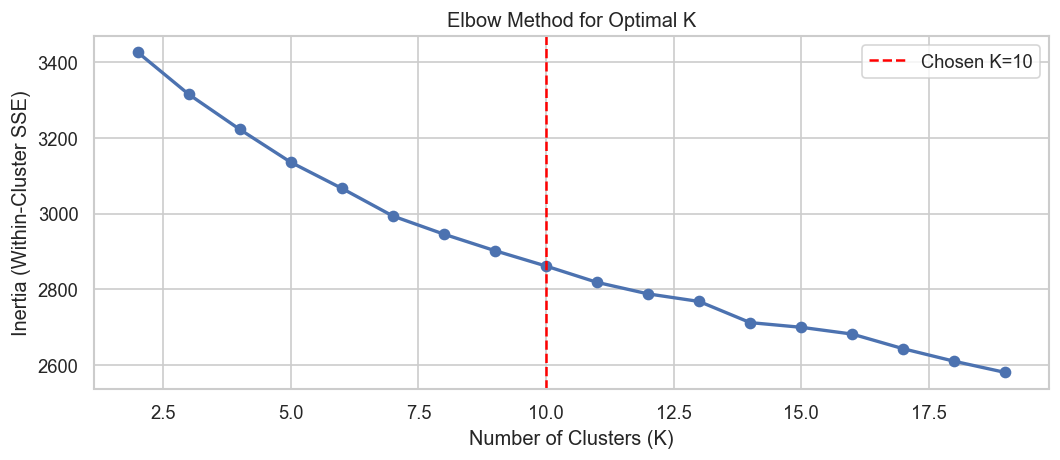

Elbow plot saved.


In [10]:
inertias = []
K_range  = range(2, 20)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)

plt.figure(figsize=(9,4))
plt.plot(list(K_range), inertias, "bo-", linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow Method for Optimal K")
plt.axvline(x=10, color="red", linestyle="--", label="Chosen K=10")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"elbow_plot.png"), bbox_inches="tight")
plt.show()
print("Elbow plot saved.")


In [11]:
K_BEST = 10
kmeans = KMeans(n_clusters=K_BEST, random_state=42, n_init=15)
df["cluster"] = kmeans.fit_predict(tfidf_matrix)

def label_cluster(idx_list):
    tc = defaultdict(int)
    for i in idx_list:
        for t in df.loc[i,"topics_list"]: tc[t] += 1
    return max(tc, key=tc.get) if tc else "misc"

cluster_labels = {c: label_cluster(df[df["cluster"]==c].index.tolist()) for c in range(K_BEST)}
df["cluster_label"] = df["cluster"].map(cluster_labels)

print("Cluster distribution:")
display(df.groupby(["cluster","cluster_label"]).size().reset_index(name="count"))

with open(os.path.join(SAVE_DIR,"kmeans_model.pkl"),"wb")  as f: pickle.dump(kmeans,f)
with open(os.path.join(SAVE_DIR,"cluster_labels.pkl"),"wb") as f: pickle.dump(cluster_labels,f)
print("KMeans model and cluster labels saved.")


Cluster distribution:


,cluster,cluster_label,count
0,0,array,404
1,1,hash table,627
2,2,tree,372
3,3,bit manipulation,152
4,4,array,752
5,5,linked list,261
6,6,breadth-first search,268
7,7,two pointers,322
8,8,stack,221
9,9,dynamic programming,454


KMeans model and cluster labels saved.


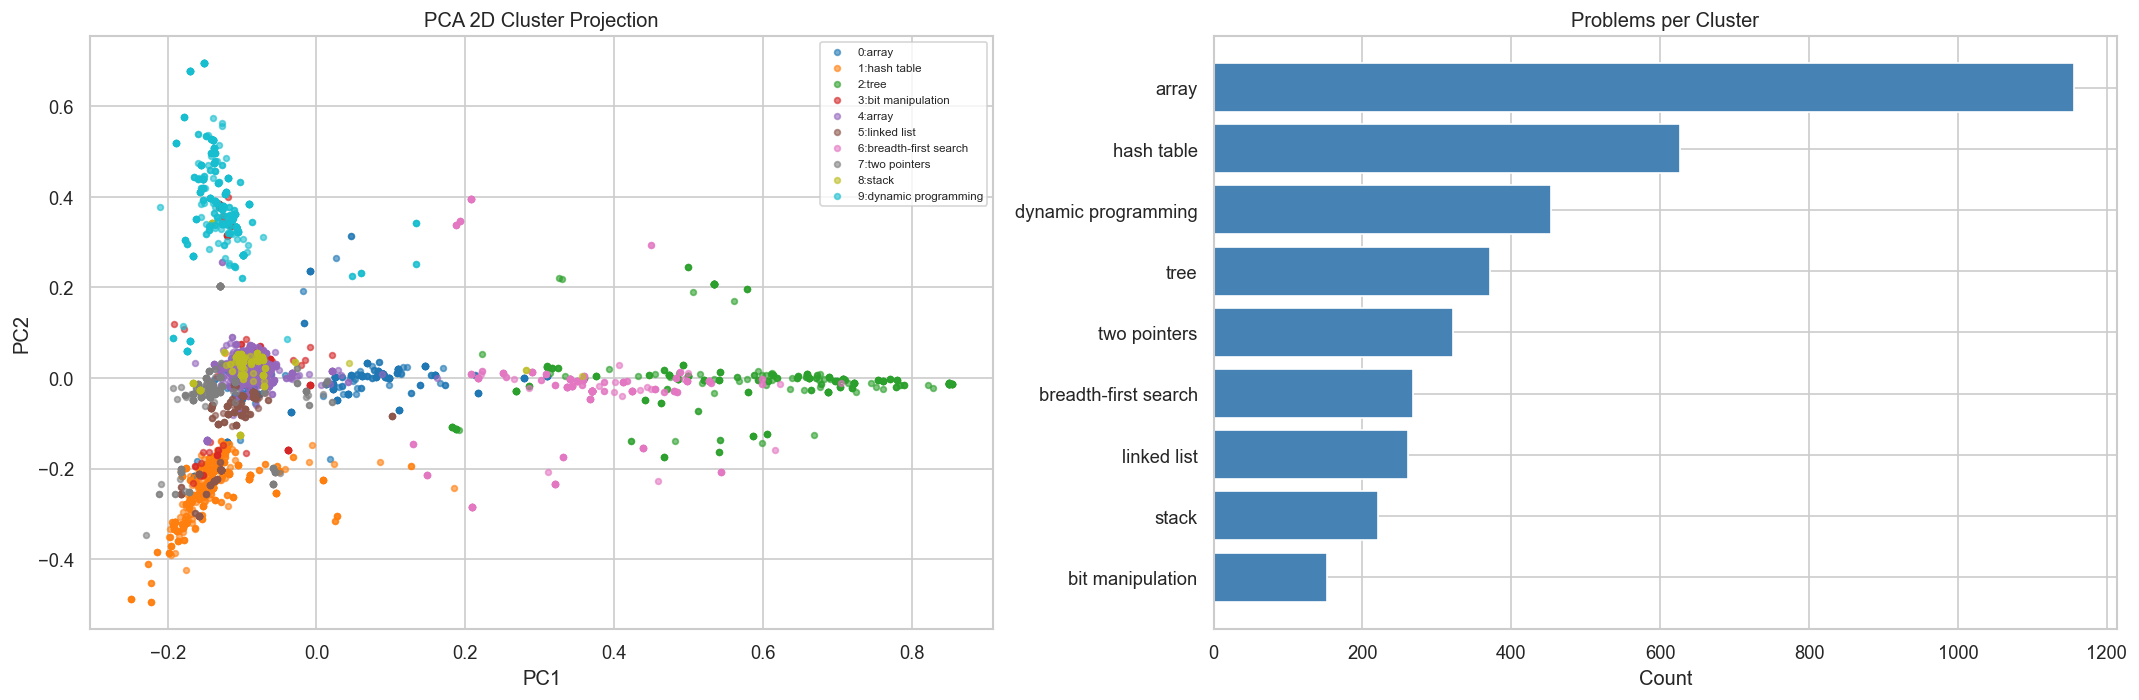

Cluster visualisation saved.


In [12]:
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
df["pca_x"] = coords[:,0]
df["pca_y"] = coords[:,1]

fig, axes = plt.subplots(1,2,figsize=(18,6))
palette = cm.tab10(np.linspace(0,1,K_BEST))
for c in range(K_BEST):
    mask = df["cluster"]==c
    axes[0].scatter(df.loc[mask,"pca_x"], df.loc[mask,"pca_y"],
                    s=12, alpha=0.6, color=palette[c],
                    label=f"{c}:{cluster_labels[c]}")
axes[0].set_title("PCA 2D Cluster Projection")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=7)

sizes = df["cluster_label"].value_counts()
axes[1].barh(sizes.index, sizes.values, color="steelblue")
axes[1].set_title("Problems per Cluster")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"cluster_visualization.png"), bbox_inches="tight")
plt.show()

with open(os.path.join(SAVE_DIR,"pca_model.pkl"),"wb") as f: pickle.dump(pca,f)
print("Cluster visualisation saved.")


In [13]:
df["median_freq"] = df.groupby("company")["frequency"].transform("median")
df["is_frequent"] = (df["frequency"] > df["median_freq"]).astype(int)

le_diff = LabelEncoder()
le_cat  = LabelEncoder()
df["diff_enc"] = le_diff.fit_transform(df["difficulty"].fillna("Medium"))
df["cat_enc"]  = le_cat.fit_transform(df["category"].fillna("Algorithms"))

FEATURES = ["frequency","difficulty_num","acceptance_rate",
            "likes","dislikes","freq_score","relevance_score",
            "diff_enc","cat_enc","cluster"]
TARGET = "is_frequent"

model_df = df[FEATURES+[TARGET]].dropna()
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["Low Freq","High Freq"]))


Train: 3066  |  Test: 767
Accuracy: 0.9557
              precision    recall  f1-score   support

    Low Freq       0.97      0.96      0.96       489
   High Freq       0.93      0.95      0.94       278

    accuracy                           0.96       767
   macro avg       0.95      0.96      0.95       767
weighted avg       0.96      0.96      0.96       767



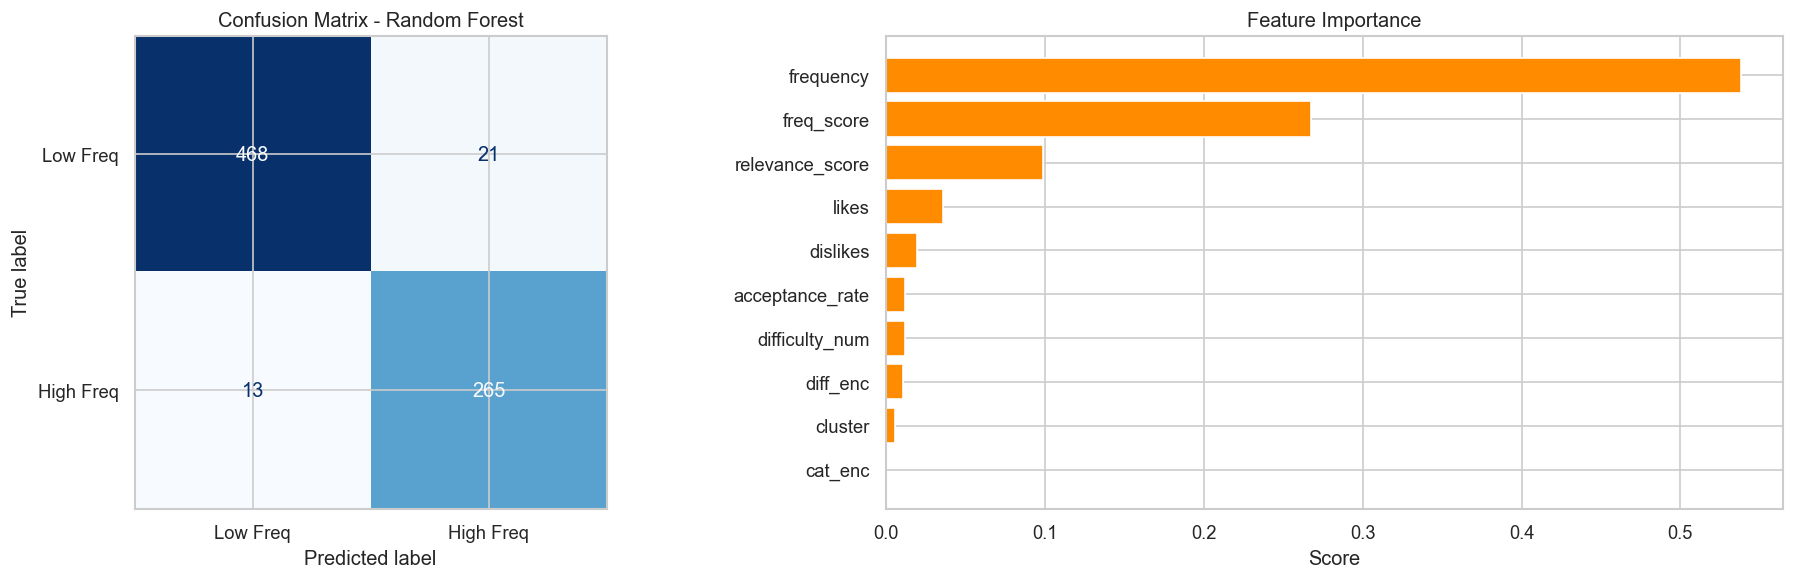

Random Forest model saved.


In [14]:
fig, axes = plt.subplots(1,2,figsize=(16,5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Low Freq","High Freq"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix - Random Forest")

imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
axes[1].barh(imp.index, imp.values, color="darkorange")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"model_evaluation.png"), bbox_inches="tight")
plt.show()

with open(os.path.join(SAVE_DIR,"rf_model.pkl"),"wb")       as f: pickle.dump(rf,f)
with open(os.path.join(SAVE_DIR,"label_encoders.pkl"),"wb") as f: pickle.dump({"difficulty":le_diff,"category":le_cat},f)
print("Random Forest model saved.")


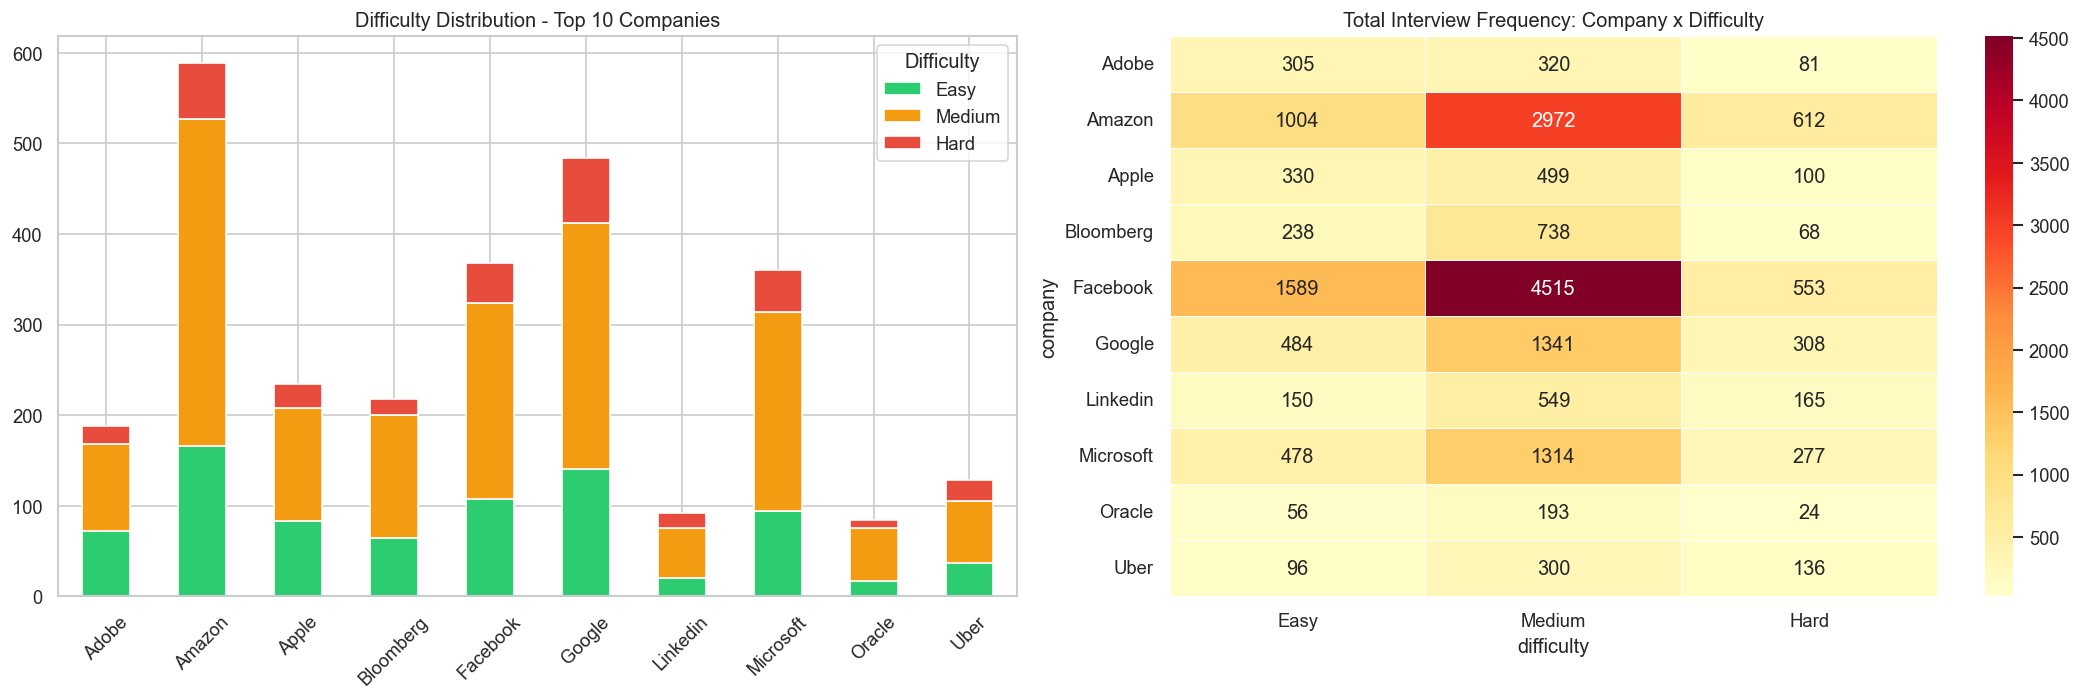

In [15]:
top10_cos = df["company"].value_counts().head(10).index.tolist()
top10_df  = df[df["company"].isin(top10_cos)]

fig, axes = plt.subplots(1,2,figsize=(18,6))

diff_pivot = (top10_df.groupby(["company","difficulty"]).size()
              .unstack(fill_value=0)
              .reindex(columns=["Easy","Medium","Hard"], fill_value=0))
diff_pivot.plot(kind="bar", stacked=True, ax=axes[0],
                color=["#2ecc71","#f39c12","#e74c3c"], edgecolor="white")
axes[0].set_title("Difficulty Distribution - Top 10 Companies")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("")
axes[0].legend(title="Difficulty")

heat = (top10_df.groupby(["company","difficulty"])["frequency"]
        .sum().unstack(fill_value=0)
        .reindex(columns=["Easy","Medium","Hard"], fill_value=0))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=axes[1])
axes[1].set_title("Total Interview Frequency: Company x Difficulty")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"company_analysis.png"), bbox_inches="tight")
plt.show()


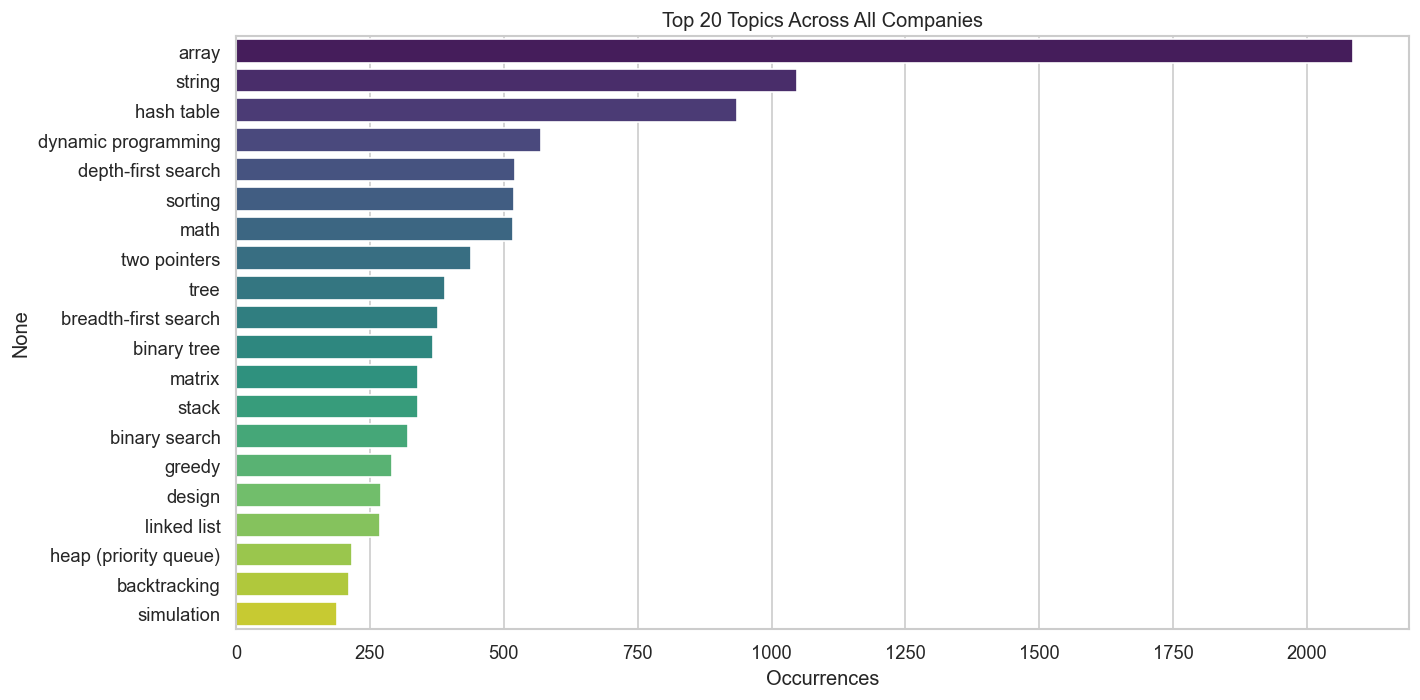

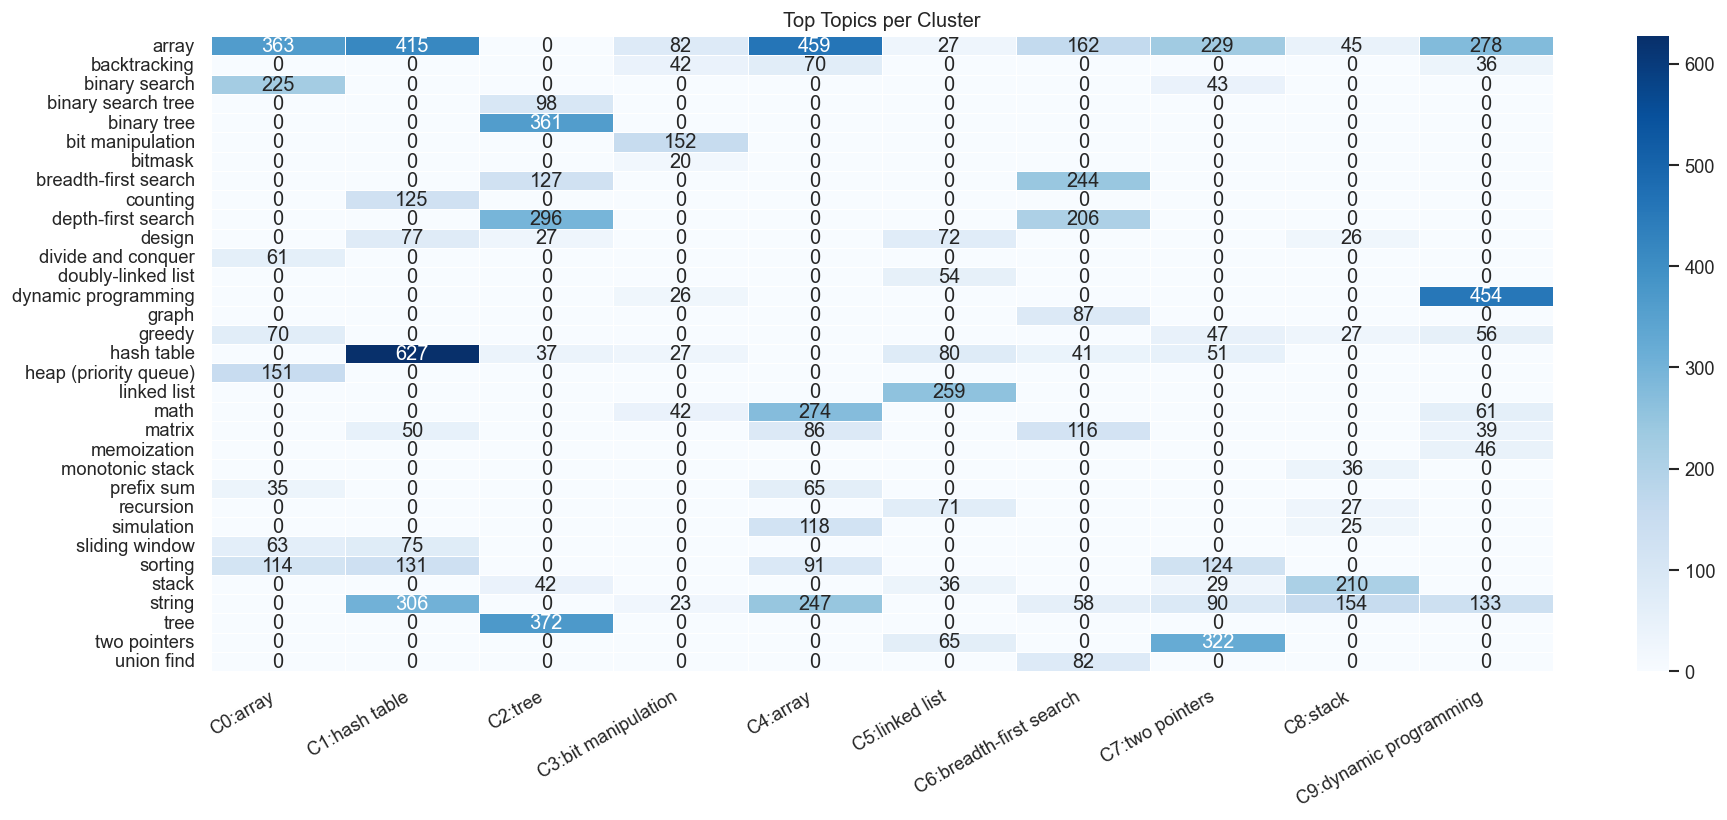

In [16]:
all_topics  = [t for row in df["topics_list"] for t in row]
topic_freq  = pd.Series(all_topics).value_counts().head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=topic_freq.values, y=topic_freq.index, palette="viridis")
plt.title("Top 20 Topics Across All Companies")
plt.xlabel("Occurrences")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"topic_frequency.png"), bbox_inches="tight")
plt.show()

ct_matrix = {}
for c in range(K_BEST):
    sub   = df[df["cluster"]==c]
    flat  = [t for row in sub["topics_list"] for t in row]
    ct_matrix[f"C{c}:{cluster_labels[c]}"] = pd.Series(flat).value_counts().head(8)

hm_df = pd.DataFrame(ct_matrix).fillna(0)
plt.figure(figsize=(16,7))
sns.heatmap(hm_df, cmap="Blues", linewidths=0.3, annot=True, fmt=".0f")
plt.title("Top Topics per Cluster")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"cluster_topic_heatmap.png"), bbox_inches="tight")
plt.show()


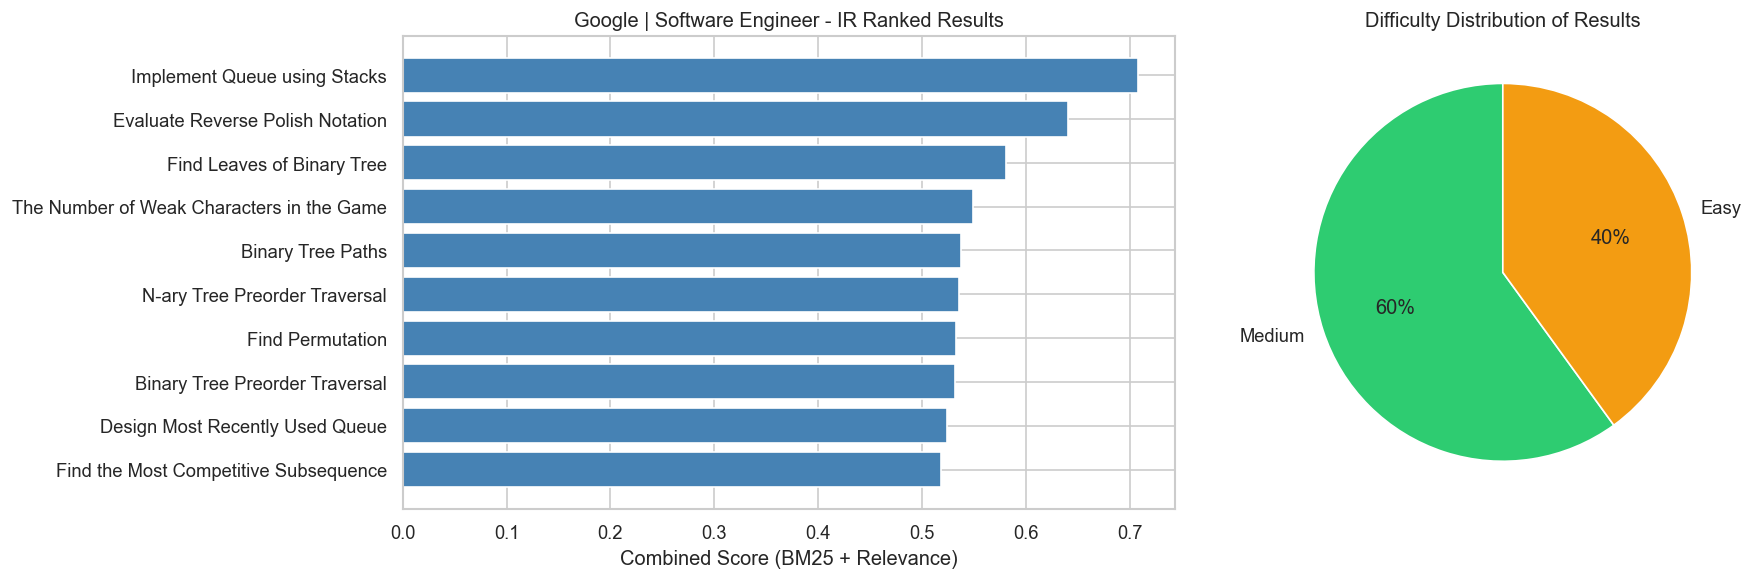

In [17]:
sample_res = query_ir("Google", "software engineer", top_k=10)

if not sample_res.empty:
    fig, axes = plt.subplots(1,2,figsize=(16,5))

    axes[0].barh(sample_res["title"][::-1],
                 sample_res["combined_score"][::-1], color="steelblue")
    axes[0].set_title("Google | Software Engineer - IR Ranked Results")
    axes[0].set_xlabel("Combined Score (BM25 + Relevance)")

    dc = sample_res["difficulty"].value_counts()
    axes[1].pie(dc.values, labels=dc.index,
                colors=["#2ecc71","#f39c12","#e74c3c"],
                autopct="%1.0f%%", startangle=90)
    axes[1].set_title("Difficulty Distribution of Results")

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR,"query_result_google_swe.png"), bbox_inches="tight")
    plt.show()


In [ ]:
save_cols = ["problem_id","title","company","frequency","difficulty","topics",
             "acceptance_rate","premium","category","likes","dislikes",
             "freq_score","difficulty_num","relevance_score",
             "cluster","cluster_label","is_frequent","url"]
save_cols = [c for c in save_cols if c in df.columns]

df[save_cols].to_csv(r'C:\Users\sribaladitya\final_ir_dataset.csv', index=False)

with open(os.path.join(SAVE_DIR,"role_topics.pkl"),"wb") as f: pickle.dump(ROLE_TOPICS,f)
df.to_parquet(os.path.join(SAVE_DIR,"ir_df.parquet"), index=False)

artifacts = [
    "company_index.pkl","topic_index.pkl","compound_index.pkl",
    "tfidf_vectorizer.pkl","tfidf_matrix.npz","bm25_index.pkl",
    "kmeans_model.pkl","cluster_labels.pkl","pca_model.pkl",
    "rf_model.pkl","label_encoders.pkl","role_topics.pkl","ir_df.parquet",
    "elbow_plot.png","cluster_visualization.png","model_evaluation.png",
    "company_analysis.png","topic_frequency.png","cluster_topic_heatmap.png",
    "query_result_google_swe.png"
]
print("="*55)
print("  ALL IR ARTIFACTS")
print("="*55)
for a in artifacts:
    path = os.path.join(SAVE_DIR,a)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"[{status}] {a}")
print(f"\nFinal dataset : final_ir_dataset.csv  shape={df.shape}")
print(f"Companies     : {df['company'].nunique()}")
print(f"Clusters      : {df['cluster'].nunique()}")


  ALL IR ARTIFACTS
[OK] company_index.pkl
[OK] topic_index.pkl
[OK] compound_index.pkl
[OK] tfidf_vectorizer.pkl
[OK] tfidf_matrix.npz
[OK] bm25_index.pkl
[OK] kmeans_model.pkl
[OK] cluster_labels.pkl
[OK] pca_model.pkl
[OK] rf_model.pkl
[OK] label_encoders.pkl
[OK] role_topics.pkl
[OK] ir_df.parquet
[OK] elbow_plot.png
[OK] cluster_visualization.png
[OK] model_evaluation.png
[OK] company_analysis.png
[OK] topic_frequency.png
[OK] cluster_topic_heatmap.png
[OK] query_result_google_swe.png

Final dataset : final_ir_dataset.csv  shape=(3833, 27)
Companies     : 187
Clusters      : 10
